Text(0.5, 1.0, '3V Model')

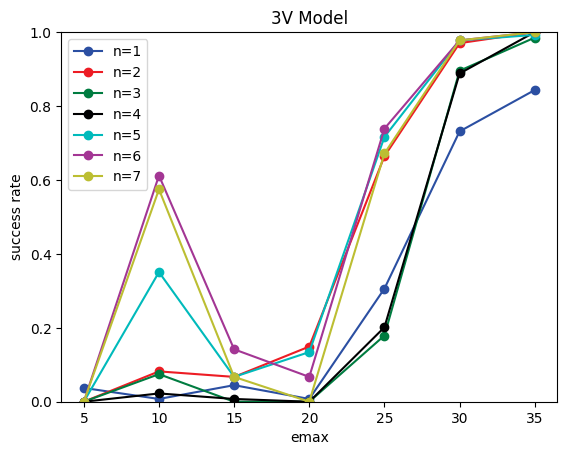

In [25]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

success_rate = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
colors = ['#2b4fa2','#ed1c24','#007c40','#000001','#00babb','#a33694','#bcbe32']

data2 = {}
dt = 0.5

with open('FTE_result.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else None for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            data2[i_idx][j_idx] = values
n = 1
for E_max in sorted(data2[1].keys()):
    if E_max > 35 or E_max < 5:
        continue
    for IC_idx in data2.keys():
        if len(data2[IC_idx][E_max]) <= 250/dt:
                success_rate[E_max][n][IC_idx] += 1.0 / (      len(data2.keys())        )
data2 = {}
dt = 0.5

with open('FTE_results_n7.csv', 'r') as f:
    lines = f.readlines()
    
    for k in range(0, len(lines), 2):
        header = lines[k].strip()  # e.g., "IC1_mask1"
        
        # 1. Use Regex to extract the numbers from the header
        # This looks for digits (\d+) after 'IC' and 'mask'
        match = re.search(r'IC(\d+)_Emax(\d+)_n(\d+)', header)
        
        if match:
            i_idx = int(match.group(1))
            j_idx = int(match.group(2))
            n_idx = int(match.group(3))
            
            # 2. Parse the data2 line into a list of floats
            values = [float(x) if x else 0 for x in lines[k+1].strip().split(',')]
            
            # 3. Build the nested dictionary structure
            if i_idx not in data2:
                data2[i_idx] = {}
            if j_idx not in data2[i_idx]:
                data2[i_idx][j_idx] = {}
            if n_idx not in data2[i_idx][j_idx]:
                data2[i_idx][j_idx][n_idx] = []
            data2[i_idx][j_idx][n_idx] = values
for E_max in sorted(data2[1].keys()):
    for IC_idx in data2.keys():
        for n_idx in data2[IC_idx][E_max].keys():
            if len(data2[IC_idx][E_max][n_idx]) <= 250/dt:
                success_rate[E_max][n_idx][IC_idx] += 1.0 / (      len(data2.keys())        )

for n in range(1,8):
    plt.plot(sorted(success_rate.keys()), [sum([i for i in success_rate[E_max][n].values()]) for E_max in sorted(success_rate.keys())],'-o',label=f'n={n}',color=colors[n-1])
plt.ylim(0,1)
plt.legend()
plt.xlabel('emax')
plt.ylabel('success rate')
plt.savefig('success_rate_vs_emax_etimeact.png')
plt.title('3V Model')


C:\Users\xan37\AppData\Local\Temp\ipykernel_62188\3662798107.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, '3V Model')

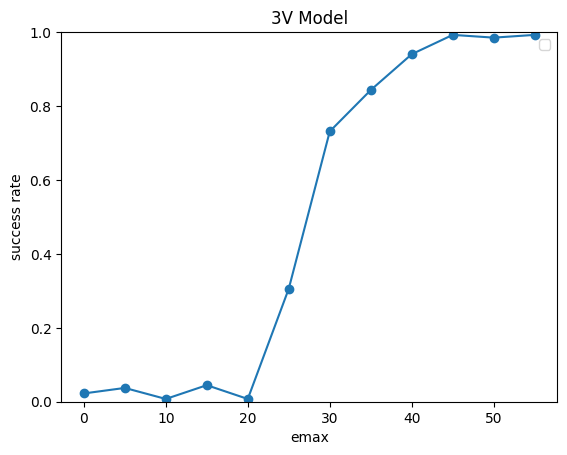